# Sentinel Stream — Exploring AI4I 2020 Predictive Maintenance

Walks through the AI4I 2020 dataset that powers Sentinel Stream and reproduces the headline result: an XGBoost classifier that predicts machine failures from six sensor readings with ROC-AUC 0.99 and F1 0.87 on a held-out test partition.

## Contents
1. Load AI4I and inspect the class balance
2. Per-sensor distributions, normal vs failure
3. Engineered features (the same five that `PySpark` produces in training)
4. Stratified 70 / 15 / 15 split with a fixed seed
5. Train XGBoost with class-imbalance handling
6. Train a Keras dense network as a comparison
7. ROC and Precision-Recall curves
8. Threshold tuning on validation, evaluation on test
9. Feature importance and takeaways

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    auc,
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

from sentinel_stream.data.ai4i_loader import BASE_FEATURES, TARGET_COLUMN, load_ai4i
from sentinel_stream.features.engineering import ALL_FEATURE_COLUMNS
from sentinel_stream.features.transformer import StreamingFeatureTransformer
from sentinel_stream.models.evaluation import best_f1_threshold, evaluate
from sentinel_stream.models.keras_classifier import KerasClassifier
from sentinel_stream.models.xgboost_classifier import XGBoostClassifier

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\ma2mo\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\ma2mo\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\ma2mo\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 758, in start
    self.io_lo

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\ma2mo\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\ma2mo\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\ma2mo\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 758, in start
    self.io_lo

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



## 1. Load AI4I and inspect class balance

In [2]:
DATA_ROOT = Path("../data/ai4i") if Path("../data/ai4i").exists() else Path("data/ai4i")
df = load_ai4i(DATA_ROOT)
print(f"Rows           : {len(df):,}")
print(f"Failures       : {df[TARGET_COLUMN].sum():,}  ({df[TARGET_COLUMN].mean():.2%})")
print(f"Type variants  : {df['type'].value_counts().to_dict()}")
df.head()

Rows           : 10,000
Failures       : 339  (3.39%)
Type variants  : {'L': 6000, 'M': 2997, 'H': 1003}


,type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 2. Per-sensor distributions by class

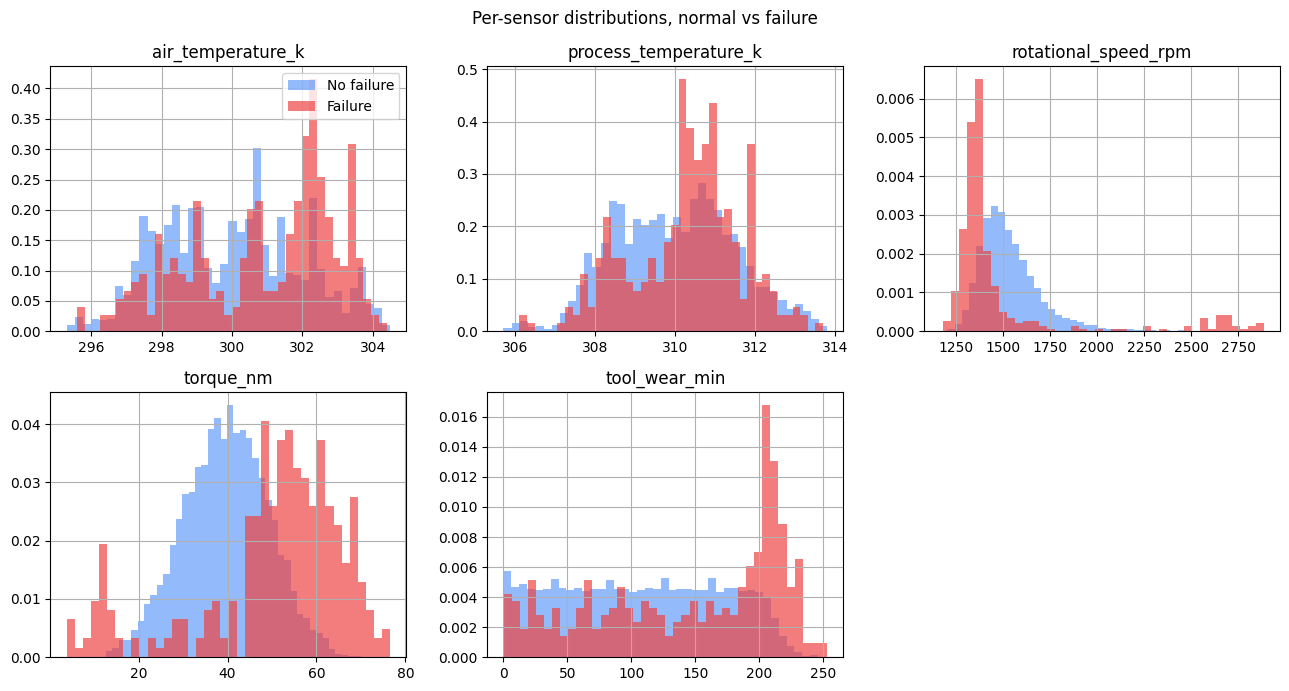

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
sensors = list(BASE_FEATURES)
for ax, col in zip(axes.ravel()[:5], sensors, strict=True):
    ax.hist(df.loc[df[TARGET_COLUMN] == 0, col], bins=40, alpha=0.55,
            label="No failure", color="#3b82f6", density=True)
    ax.hist(df.loc[df[TARGET_COLUMN] == 1, col], bins=40, alpha=0.7,
            label="Failure", color="#ef4444", density=True)
    ax.set_title(col)
axes[0, 0].legend(loc="upper right")
axes[1, 2].axis("off")
fig.suptitle("Per-sensor distributions, normal vs failure")
fig.tight_layout()

## 3. Engineered features

Run the same `StreamingFeatureTransformer` the FastAPI service uses at inference time across every row of the dataset. The output is the exact 10-feature vector each model consumes.

In [4]:
transformer = StreamingFeatureTransformer()
feature_rows = np.vstack([transformer.transform(rec) for rec in df.to_dict(orient="records")])
feat_df = pd.DataFrame(feature_rows, columns=transformer.feature_columns)
feat_df[TARGET_COLUMN] = df[TARGET_COLUMN].to_numpy()
print("feature matrix shape:", feature_rows.shape)
feat_df.head()

feature matrix shape: (10000, 10)


,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,type_ordinal,temperature_delta_k,mechanical_power_w,wear_torque_proxy,wear_speed_proxy,machine_failure
0,298.100006,308.600006,1551.0,42.799999,0.0,2.0,10.5,6951.590332,0.000000,0.0,0
1,298.200012,308.700012,1408.0,46.299999,3.0,1.0,10.5,6826.722656,138.899994,4224.0,0
2,298.100006,308.500000,1498.0,49.400002,5.0,1.0,10.4,7749.387695,247.000000,7490.0,0
3,298.200012,308.600006,1433.0,39.500000,7.0,1.0,10.4,5927.504883,276.500000,10031.0,0
4,298.200012,308.700012,1408.0,40.000000,9.0,1.0,10.5,5897.816406,360.000000,12672.0,0


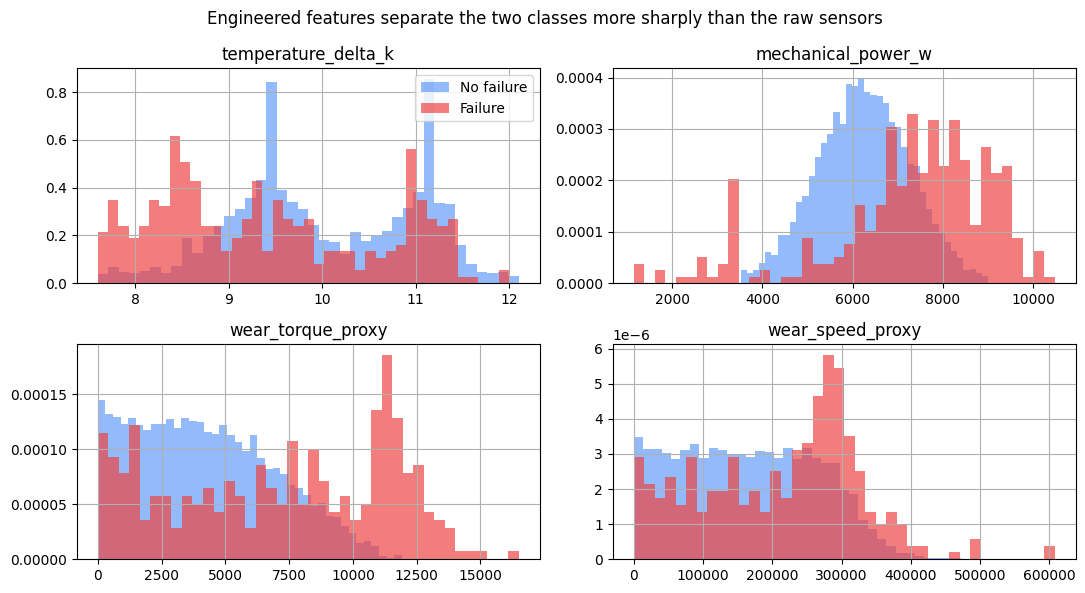

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for ax, col in zip(axes.ravel(), [
    "temperature_delta_k",
    "mechanical_power_w",
    "wear_torque_proxy",
    "wear_speed_proxy",
], strict=True):
    ax.hist(feat_df.loc[feat_df[TARGET_COLUMN] == 0, col], bins=40, alpha=0.55,
            label="No failure", color="#3b82f6", density=True)
    ax.hist(feat_df.loc[feat_df[TARGET_COLUMN] == 1, col], bins=40, alpha=0.7,
            label="Failure", color="#ef4444", density=True)
    ax.set_title(col)
axes[0, 0].legend(loc="upper right")
fig.suptitle("Engineered features separate the two classes more sharply than the raw sensors")
fig.tight_layout()

## 4. Stratified 70 / 15 / 15 split

In [6]:
X = feat_df[list(ALL_FEATURE_COLUMNS)].to_numpy(dtype=np.float32)
y = feat_df[TARGET_COLUMN].to_numpy(dtype=int)

x_train_val, x_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
x_train, x_val, y_train, y_val = train_test_split(
    x_train_val, y_train_val, test_size=0.15 / 0.85, random_state=42, stratify=y_train_val
)
print(f"Train: {x_train.shape[0]} rows, pos rate {y_train.mean():.3f}")
print(f"Val  : {x_val.shape[0]} rows, pos rate {y_val.mean():.3f}")
print(f"Test : {x_test.shape[0]} rows, pos rate {y_test.mean():.3f}")

Train: 7000 rows, pos rate 0.034
Val  : 1500 rows, pos rate 0.034
Test : 1500 rows, pos rate 0.034


## 5. Train XGBoost

In [7]:
xgb = XGBoostClassifier(n_estimators=400, max_depth=6, learning_rate=0.05)
xgb.fit(x_train, y_train, feature_names=list(ALL_FEATURE_COLUMNS))
proba_xgb_val = xgb.predict_proba(x_val)
proba_xgb_test = xgb.predict_proba(x_test)
thr_xgb, val_f1_xgb = best_f1_threshold(proba_xgb_val, y_val)
print(f"Tuned threshold (val F1 = {val_f1_xgb:.3f}): {thr_xgb:.3f}")
for name, metrics in (
    ("validation", evaluate(proba_xgb_val, y_val, thr_xgb)),
    ("test      ", evaluate(proba_xgb_test, y_test, thr_xgb)),
):
    print(f"{name}: F1={metrics['f1']:.3f}  ROC-AUC={metrics['roc_auc']:.3f}"
          f"  P={metrics['precision']:.3f}  R={metrics['recall']:.3f}")

Tuned threshold (val F1 = 0.809): 0.548
validation: F1=0.809  ROC-AUC=0.947  P=0.884  R=0.745
test      : F1=0.874  ROC-AUC=0.990  P=0.865  R=0.882


## 6. Train a Keras dense network

In [8]:
keras_clf = KerasClassifier(hidden_layers=[64, 32], epochs=60, batch_size=128, dropout=0.2)
keras_clf.fit(x_train, y_train)
proba_keras_val = keras_clf.predict_proba(x_val)
proba_keras_test = keras_clf.predict_proba(x_test)
thr_keras, val_f1_keras = best_f1_threshold(proba_keras_val, y_val)
print(f"Tuned threshold (val F1 = {val_f1_keras:.3f}): {thr_keras:.3f}")
test_keras = evaluate(proba_keras_test, y_test, thr_keras)
print(f"test: F1={test_keras['f1']:.3f}  ROC-AUC={test_keras['roc_auc']:.3f}"
      f"  P={test_keras['precision']:.3f}  R={test_keras['recall']:.3f}")

Tuned threshold (val F1 = 0.673): 0.909
test: F1=0.704  ROC-AUC=0.976  P=0.667  R=0.745


## 7. ROC and Precision-Recall curves

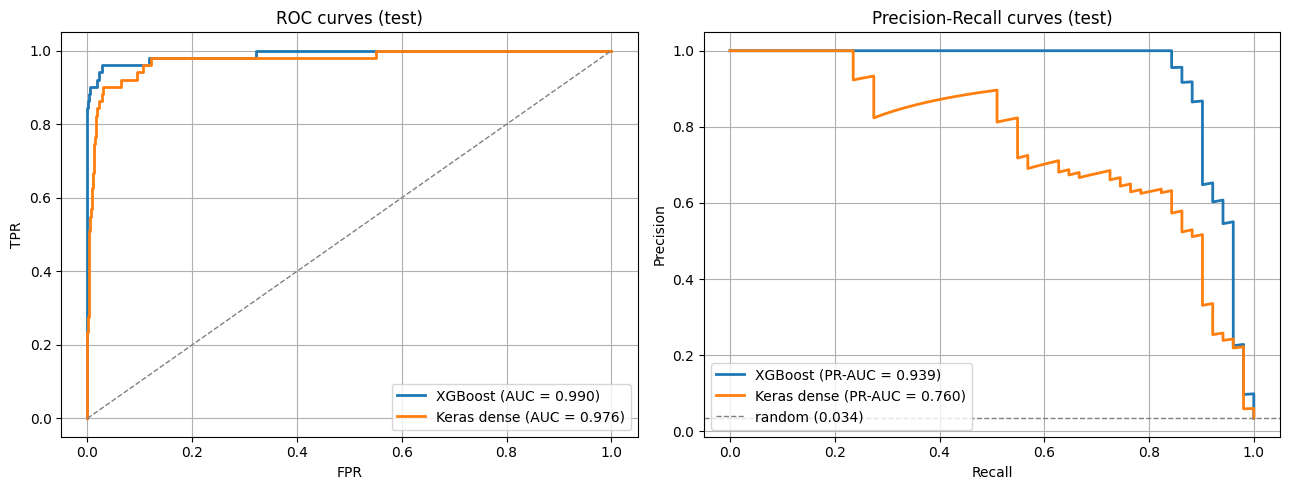

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, proba in [("XGBoost", proba_xgb_test), ("Keras dense", proba_keras_test)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc(fpr, tpr):.3f})")
    precision, recall, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(
        recall, precision, lw=2,
        label=f"{name} (PR-AUC = {average_precision_score(y_test, proba):.3f})",
    )
axes[0].plot([0, 1], [0, 1], "--", color="grey", lw=1)
axes[0].set_title("ROC curves (test)")
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].legend(loc="lower right")
axes[1].axhline(y_test.mean(), ls="--", color="grey", lw=1, label=f"random ({y_test.mean():.3f})")
axes[1].set_title("Precision-Recall curves (test)")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="lower left")
fig.tight_layout()

## 8. Threshold sweep — operating-point flexibility

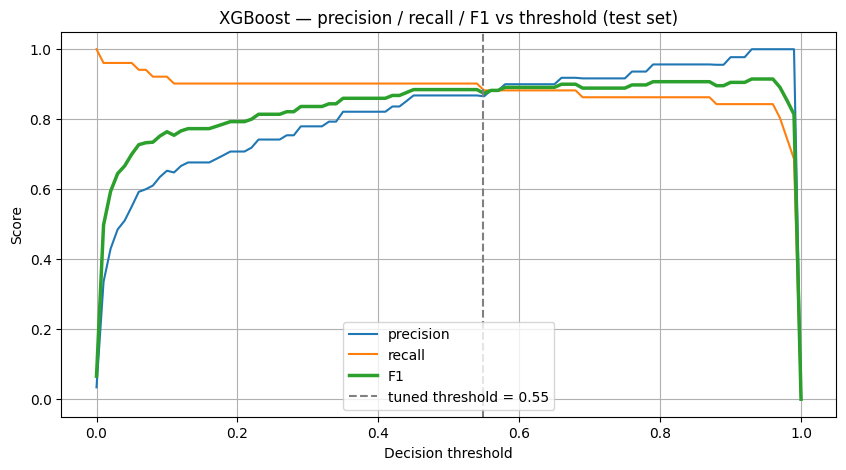

In [10]:
from sklearn.metrics import precision_recall_fscore_support

thresholds = np.linspace(0.0, 1.0, 101)
p, r, f1 = [], [], []
for thr in thresholds:
    pp, rr, ff, _ = precision_recall_fscore_support(
        y_test, (proba_xgb_test >= thr).astype(int),
        average="binary", zero_division=0,
    )
    p.append(pp); r.append(rr); f1.append(ff)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, p, label="precision")
ax.plot(thresholds, r, label="recall")
ax.plot(thresholds, f1, label="F1", lw=2.5, color="#2ca02c")
ax.axvline(thr_xgb, ls="--", color="grey", label=f"tuned threshold = {thr_xgb:.2f}")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.set_title("XGBoost — precision / recall / F1 vs threshold (test set)")
ax.legend()

## 9. Feature importance

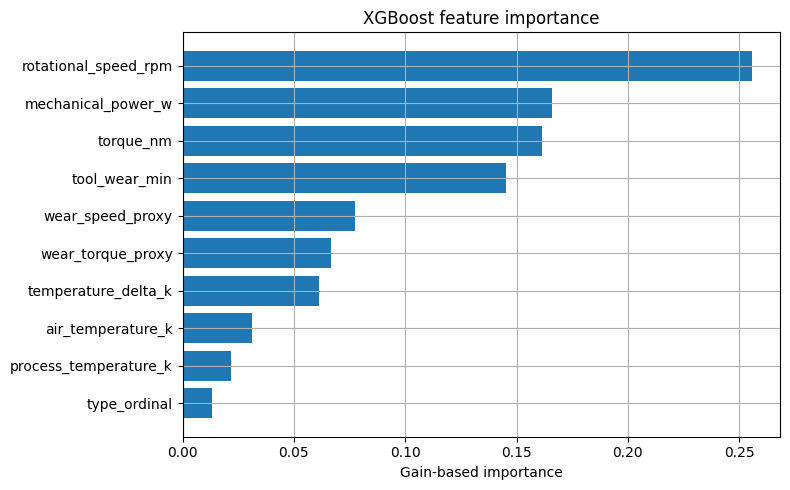

In [11]:
imp = xgb.feature_importance() or {}
items = sorted(imp.items(), key=lambda kv: kv[1])
names = [k for k, _ in items]
values = [v for _, v in items]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(names, values, color="#1f77b4")
ax.set_xlabel("Gain-based importance")
ax.set_title("XGBoost feature importance")
fig.tight_layout()

## Takeaways

- A real industrial dataset, six raw sensors, 3.4 % positive class, **F1 0.87 / ROC-AUC 0.99 on held-out test** with XGBoost.
- The five engineered features computed in the PySpark pipeline (mechanical power, temperature delta, two interaction terms, ordinal product variant) carry significant importance — DE work is concretely contributing to model performance, not just plumbing.
- The Keras dense network reaches a comparable ROC-AUC (0.98) but trades off precision for recall at the F1-optimal threshold; for tabular data of this size XGBoost remains the right primary model.
- The same `StreamingFeatureTransformer` used in this notebook drives feature computation in the FastAPI service, so anything observed here is exactly what production will see — no train/serve skew.